<div dir='rtl'>

# AI Journey — از صفر تا Agent

> **هدف این نوت‌بوک:** یاد بگیریم یک سیستم هوشمند واقعاً چگونه از داده یاد می‌گیرد؛ از یک مدل خطی بسیار ساده شروع می‌کنیم و قدم‌به‌قدم به شبکه‌های عصبی، یادگیری تقویتی و Agentها می‌رسیم.

این نوت‌بوک قرار نیست فقط مجموعه‌ای از کدهای آماده باشد. در هر مرحله سه سؤال را دنبال می‌کنیم:

1. **چه اتفاقی می‌افتد؟** — شهودی و ساده
2. **چرا این اتفاق می‌افتد؟** — ریاضیات
3. **چطور خودمان پیاده‌سازی‌اش کنیم؟** — کدنویسی و آزمایش

</div>

<div dir='rtl'>

## نقشه‌ی مسیر

```text
AI Journey
│
├── 01. Machine Learning از صفر
│   ├── Data
│   ├── Model
│   ├── Prediction
│   ├── Loss
│   └── Gradient Descent
│
├── 02. Linear Regression چندویژگی
├── 03. Classification و Perceptron
├── 04. Neuron و Activation Functions
├── 05. Neural Networks
│   ├── Forward Pass
│   ├── Loss
│   └── Backpropagation
├── 06. Deep Learning با NumPy
├── 07. PyTorch — از مفهوم تا Framework
├── 08. CNN / Vision
├── 09. Sequence و Transformer
├── 10. Reinforcement Learning
└── 11. پروژه‌ی نهایی: ساخت Agent
```

### قانون مهم
هر فصل تا وقتی مفهومی را با **مشاهده و آزمایش** نفهمیده‌ایم، به فصل بعد نمی‌رویم.

</div>

<div dir='rtl'>

## روش یادگیری در هر فصل

برای هر مفهوم از این الگو استفاده می‌کنیم:

**پیاده سازی از صفر -> ریاضیات -> شهود -> آزمایش -> چالش**

سؤال مرکزی این فصل:

> چگونه یک مدل می‌تواند خودش پارامترهایش را تغییر دهد تا خطایش کمتر شود؟

</div>

<div dir='rtl'>

# 01 — Machine Learning از صفر

## هدف فصل

در پایان این فصل باید بتوانیم بدون استفاده از کتابخانه‌های Machine Learning، یک **Linear Regression** ساده را از صفر بسازیم و دقیقاً بفهمیم:

- Data، Model و Prediction چه هستند؟
- Loss چیست و چرا به آن نیاز داریم؟
- Gradient چه چیزی را اندازه می‌گیرد؟
- Gradient Descent چگونه پارامترها را به‌روزرسانی می‌کند؟
- چگونه روند یادگیری مدل را ببینیم؟

</div>

<div dir='rtl'>

## 1.1 — مسئله را عمداً خیلی ساده می‌کنیم

داده‌های ما:

<div align='center'>

| x | y |
|---:|---:|
| 1 | 2 |
| 2 | 4 |
| 3 | 6 |
| 4 | 8 |

</div>

الگوی ساده‌ی پشت داده‌ها تقریباً `y = 2x` است.

اما **مدل این قانون را از قبل نمی‌داند**؛ فقط داده را می‌بیند و باید پارامترهای مناسب را پیدا کند.

</div>

In [11]:
# فقط Python ساده؛ هنوز هیچ کتابخانه‌ی ML استفاده نمی‌کنیم.
X = [1, 2, 3, 4]
Y = [2, 4, 6, 8]

print('X =', X)
print('Y =', Y)

X = [1, 2, 3, 4]
Y = [2, 4, 6, 8]


<div dir='rtl'>

## 1.2 — Model چیست؟

ساده‌ترین مدل ما یک خط است:

</div>

$$
y_{pred} = wx + b
$$

<div dir='rtl'>

- `w` = وزن؛ شیب خط را کنترل می‌کند.
- `b` = بایاس؛ خط را جابه‌جا می‌کند.
- `y_pred` = پیش‌بینی مدل.

در شروع `w` و `b` را عمداً بد انتخاب می‌کنیم؛ مدل باید آن‌ها را **یاد بگیرد**.

</div>

In [12]:
w = 0.5
b = 0.0


def predict(x, w, b):
    return w * x + b

Y_pred = [predict(x, w, b) for x in X]
print('Predictions:', Y_pred)

Predictions: [0.5, 1.0, 1.5, 2.0]


<div dir='rtl'>

## 1.3 — قبل از یادگیری، مدل چقدر بد است؟

برای اندازه‌گیری خطا، از Mean Squared Error استفاده می‌کنیم:

</div>

$$
MSE = \frac{1}{n} \sum_{i=1}^{n}(y_i - \hat y_i)^2
$$

<div dir='rtl'>

این همان **Loss Function** ماست.

> فعلاً فقط یک سؤال داریم: «مدل چقدر بد است؟»

</div>

In [13]:
def mse(y_true, y_pred):
    n = len(y_true)
    return sum((y_true[i] - y_pred[i]) ** 2 for i in range(n)) / n

loss = mse(Y, Y_pred)
print(f'MSE = {loss:.4f}')

MSE = 16.8750


<div dir='rtl'>

## 1.4 — Visualization: مدل فعلی را ببینیم 👀

نقطه‌ها داده‌ی واقعی هستند و خط، چیزی است که مدل فعلاً تصور می‌کند.

</div>

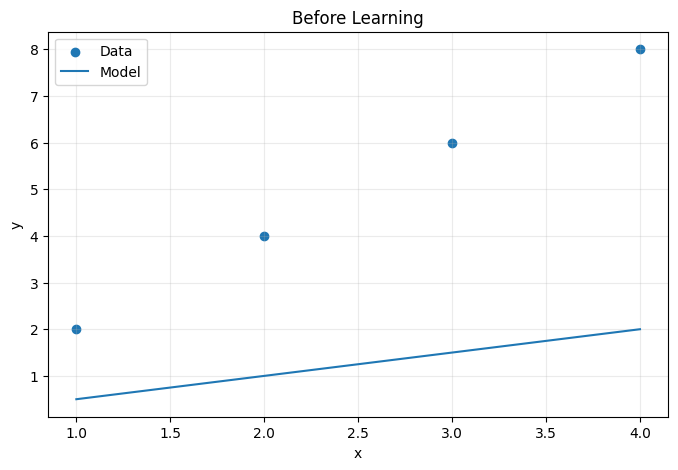

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(X, Y, label='Data')
line_x = [1, 4]
line_y = [predict(x, w, b) for x in line_x]
plt.plot(line_x, line_y, label='Model')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Before Learning')
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

<div dir='rtl'>

## 1.5 — سؤال اصلی: مدل از کجا بفهمد کدام طرف حرکت کند؟

اگر فقط `w` را کمی تغییر بدهیم، Loss کم می‌شود یا زیاد؟

این همان سؤالی است که **Gradient** به ما کمک می‌کند جواب بدهیم.

اول ایده را عددی امتحان می‌کنیم: یک قدم کوچک به چپ و راست می‌رویم و Loss را مقایسه می‌کنیم.

</div>

In [15]:
def loss_for_w(w_value, b_value=0.0):
    preds = [predict(x, w_value, b_value) for x in X]
    return mse(Y, preds)

current_w = 0.5
delta = 0.01
loss_left = loss_for_w(current_w - delta)
loss_current = loss_for_w(current_w)
loss_right = loss_for_w(current_w + delta)

print(f'Loss at w-delta : {loss_left:.6f}')
print(f'Loss at w       : {loss_current:.6f}')
print(f'Loss at w+delta : {loss_right:.6f}')

Loss at w-delta : 17.100750
Loss at w       : 16.875000
Loss at w+delta : 16.650750


<div dir='rtl'>

## 1.6 — Gradient Descent

Gradient جهت تغییر Loss را نشان می‌دهد. برای کم کردن Loss باید **خلاف جهت Gradient** حرکت کنیم:

</div>

$$
w \leftarrow w - \alpha \frac{\partial Loss}{\partial w}
$$

$$
b \leftarrow b - \alpha \frac{\partial Loss}{\partial b}
$$

<div dir='rtl'>

`α` همان **Learning Rate** است و اندازه‌ی هر قدم را تعیین می‌کند.

### گرادیان‌های این مسئله

</div>

$$
\frac{\partial Loss}{\partial w} = \frac{2}{n} \sum (y_{pred}-y)x
$$

$$
\frac{\partial Loss}{\partial b} = \frac{2}{n} \sum (y_{pred}-y)
$$

<div dir='rtl'>

قرار نیست این فرمول‌ها را فقط حفظ کنیم؛ هدف این است که بفهمیم Gradient یک ابزار برای پیدا کردن **جهت کاهش خطا** است.

</div>

In [16]:
def compute_gradients(X, Y, w, b):
    n = len(X)
    preds = [predict(x, w, b) for x in X]
    dw = (2 / n) * sum((preds[i] - Y[i]) * X[i] for i in range(n))
    db = (2 / n) * sum(preds[i] - Y[i] for i in range(n))
    return dw, db

<div dir='rtl'>

## 1.7 — حالا مدل واقعاً یاد می‌گیرد

در هر مرحله فقط سه کار انجام می‌دهیم:

1. Prediction
2. محاسبه‌ی Gradient
3. به‌روزرسانی `w` و `b`

همین حلقه‌ی ساده، هسته‌ی اصلی یادگیری مدل‌های بسیار پیچیده‌تر است.

</div>

In [17]:
w = 0.5
b = 0.0
learning_rate = 0.01
epochs = 1000

history = {'epoch': [], 'loss': [], 'w': [], 'b': []}

for epoch in range(epochs):
    preds = [predict(x, w, b) for x in X]
    loss = mse(Y, preds)
    dw, db = compute_gradients(X, Y, w, b)

    history['epoch'].append(epoch)
    history['loss'].append(loss)
    history['w'].append(w)
    history['b'].append(b)

    w -= learning_rate * dw
    b -= learning_rate * db

print(f'Final w = {w:.4f}')
print(f'Final b = {b:.4f}')
print(f'Final loss = {history["loss"][-1]:.6f}')

Final w = 1.9922
Final b = 0.0228
Final loss = 0.000087


<div dir='rtl'>

## 1.8 — Visualization: یادگیری را تماشا کنیم

عدد نهایی مهم است، اما دیدن **روند یادگیری** مهم‌تر است.

</div>

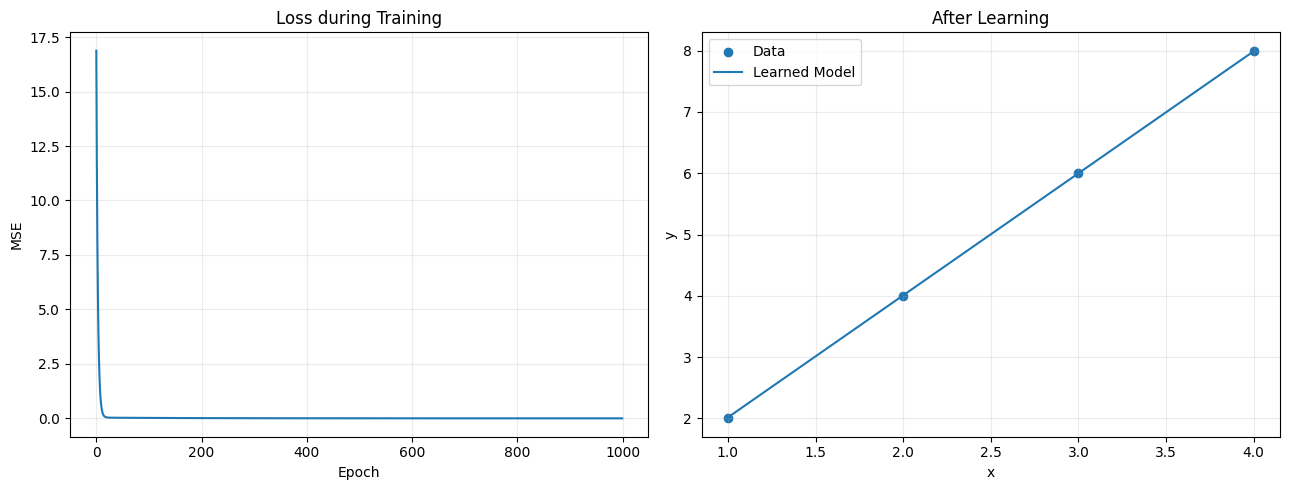

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history['epoch'], history['loss'])
axes[0].set_title('Loss during Training')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].grid(True, alpha=0.25)

axes[1].scatter(X, Y, label='Data')
line_y = [predict(x, w, b) for x in line_x]
axes[1].plot(line_x, line_y, label='Learned Model')
axes[1].set_title('After Learning')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend()
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

<div dir='rtl'>

## 1.9 — آزمایش Learning Rate

یکی از بهترین راه‌های فهمیدن یک مفهوم، خراب کردن عمدی آن است.

سه حالت را مقایسه می‌کنیم:

- `0.001` → قدم‌های خیلی کوچک
- `0.01` → قدم مناسب برای این مسئله
- `0.5` → قدم‌های بزرگ و احتمال ناپایداری

</div>

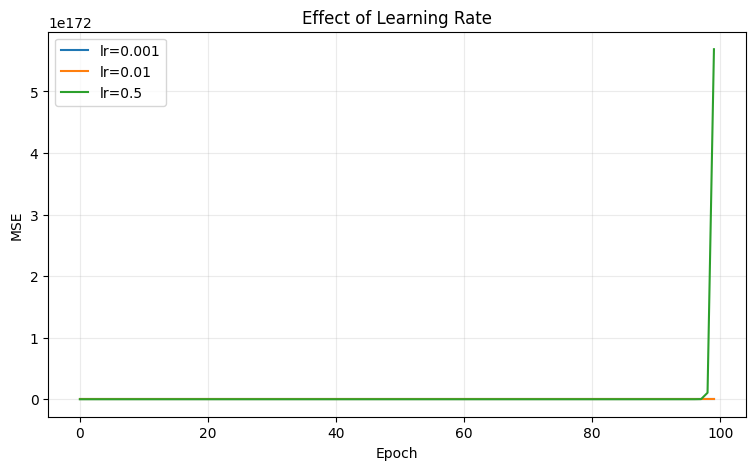

In [19]:
def train(learning_rate, epochs=100):
    w, b = 0.5, 0.0
    losses = []
    for _ in range(epochs):
        preds = [predict(x, w, b) for x in X]
        losses.append(mse(Y, preds))
        dw, db = compute_gradients(X, Y, w, b)
        w -= learning_rate * dw
        b -= learning_rate * db
    return w, b, losses

learning_rates = [0.001, 0.01, 0.5]
plt.figure(figsize=(9, 5))
for lr in learning_rates:
    _, _, losses = train(lr, epochs=100)
    plt.plot(losses, label=f'lr={lr}')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Effect of Learning Rate')
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

<div dir='rtl'>

## 1.10 — یک تست واقعی

حالا مدل را روی مقداری که در داده‌ی آموزشی ندیده است امتحان می‌کنیم.

</div>

In [20]:
test_x = 10
prediction = predict(test_x, w, b)
ideal = 2 * test_x
print(f'x = {test_x}')
print(f'Model prediction = {prediction:.4f}')
print(f'Expected value   = {ideal:.4f}')

x = 10
Model prediction = 19.9452
Expected value   = 20.0000


<div dir='rtl'>

# جمع‌بندی فصل 1

<div align='center'>

```text
Data
  ↓
Model: y = wx + b
  ↓
Prediction
  ↓
Loss (MSE)
  ↓
Gradient
  ↓
Gradient Descent
  ↓
Updated w,b
  ↓
Better Prediction
```

</div>

### نکته‌ی کلیدی

**Learning در این مثال یعنی پیدا کردن پارامترهایی که Loss را کم می‌کنند.**

بعداً همین ایده را در مدل‌های پیچیده‌تر دوباره می‌بینیم؛ فقط تعداد پارامترها بیشتر و ساختار مدل قدرتمندتر می‌شود.

</div>

<div dir='rtl'>

## Challenge فصل 1

1. مقدار اولیه‌ی `w` را از `0.5` به `10` تغییر بده. روند یادگیری چه تغییری می‌کند؟
2. `learning_rate` را برابر `0.1`، `0.2` و `1.0` کن و نمودار Loss را مقایسه کن.
3. داده‌ها را به رابطه‌ی `y = 3x + 1` تغییر بده. آیا مدل می‌تواند `w ≈ 3` و `b ≈ 1` را یاد بگیرد؟
4. یک Outlier اضافه کن. خط یادگرفته‌شده چقدر تغییر می‌کند؟

### فصل بعد

در فصل 2 از یک ویژگی به **چند ویژگی** می‌رویم و از آنجا قدم‌به‌قدم به مفهوم **Neuron** نزدیک می‌شویم.

</div>